# Feature Engineering

En este notebook se crearán nuevas variables a partir del dataset limpio obtenido en la etapa anterior.

El objetivo del feature engineering es transformar variables existentes en características más informativas para el análisis y el modelado supervisado. Estas nuevas variables permitirán representar mejor factores asociados al riesgo cardiovascular, como el índice de masa corporal, categorías de presión arterial, obesidad, riesgo metabólico y hábitos de vida.

En esta etapa se trabajará con el archivo `cardio_clean.csv`, generado después del proceso de limpieza. No se entrenarán modelos todavía; el propósito es preparar un dataset enriquecido para la siguiente fase del proyecto.

Las principales transformaciones que se realizarán son:

- Creación del índice de masa corporal (`bmi`).
- Clasificación del IMC en categorías.
- Creación de un indicador de obesidad.
- Clasificación de la presión arterial.
- Creación de un indicador de hipertensión.
- Creación de variables relacionadas con riesgo metabólico.
- Creación de variables relacionadas con hábitos de riesgo.
- Construcción de un puntaje general de riesgo cardiovascular.
- Revisión final de correlaciones con la variable objetivo `cardio`.

In [100]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

In [101]:
# Cargar dataset limpio generado en la etapa anterior
df = pd.read_csv("cardio_clean.csv")

# Vista inicial
df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.00,110,80,1,1,0,0,1,0
1,55,1,156,85.00,140,90,3,1,0,0,1,1
2,51,1,165,64.00,130,70,3,1,0,0,0,1
3,48,2,169,82.00,150,100,1,1,0,0,1,1
4,47,1,156,56.00,100,60,1,1,0,0,0,0


In [102]:
# Dimensiones del dataset limpio
df.shape

(65307, 12)

In [103]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65307 entries, 0 to 65306
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age_years    65307 non-null  int64  
 1   gender       65307 non-null  int64  
 2   height       65307 non-null  int64  
 3   weight       65307 non-null  float64
 4   ap_hi        65307 non-null  int64  
 5   ap_lo        65307 non-null  int64  
 6   cholesterol  65307 non-null  int64  
 7   gluc         65307 non-null  int64  
 8   smoke        65307 non-null  int64  
 9   alco         65307 non-null  int64  
 10  active       65307 non-null  int64  
 11  cardio       65307 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.0 MB


In [104]:
# Primeras filas
df.head()

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.00,110,80,1,1,0,0,1,0
1,55,1,156,85.00,140,90,3,1,0,0,1,1
2,51,1,165,64.00,130,70,3,1,0,0,0,1
3,48,2,169,82.00,150,100,1,1,0,0,1,1
4,47,1,156,56.00,100,60,1,1,0,0,0,0


## Creación del IMC

Se creó la variable `bmi`, correspondiente al Índice de Masa Corporal. Esta variable relaciona el peso y la altura de cada persona, por lo que puede aportar más información que analizar ambas variables por separado.

El IMC será utilizado posteriormente para crear categorías de peso y un indicador de obesidad.

In [105]:
# Crear Índice de Masa Corporal (IMC)
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# Revisar primeros registros
df[["height", "weight", "bmi"]].head()

,height,weight,bmi
0,168,62.00,21.97
1,156,85.00,34.93
2,165,64.00,23.51
3,169,82.00,28.71
4,156,56.00,23.01


In [106]:
# Estadísticas descriptivas del IMC
df["bmi"].describe()

count   65307.00
mean       27.55
std         5.23
min        12.25
25%        23.88
50%        26.54
75%        30.43
max        59.52
Name: bmi, dtype: float64

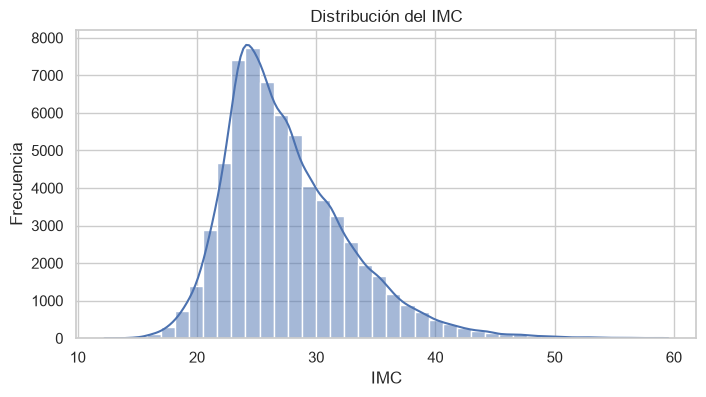

In [107]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="bmi", bins=40, kde=True)

plt.title("Distribución del IMC")
plt.xlabel("IMC")
plt.ylabel("Frecuencia")

plt.show()

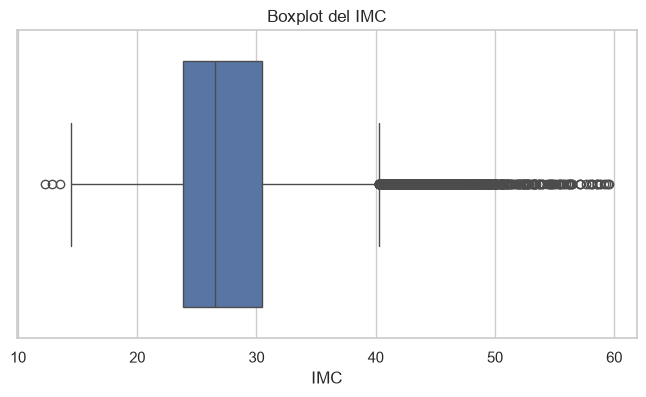

In [108]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x="bmi")

plt.title("Boxplot del IMC")
plt.xlabel("IMC")

plt.show()

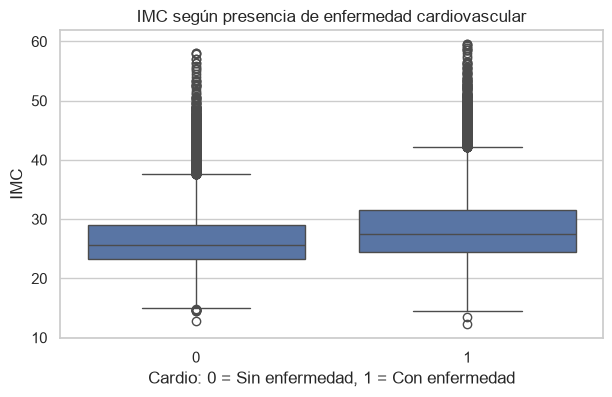

In [109]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="cardio", y="bmi")

plt.title("IMC según presencia de enfermedad cardiovascular")
plt.xlabel("Cardio: 0 = Sin enfermedad, 1 = Con enfermedad")
plt.ylabel("IMC")

plt.show()

In [110]:
# Media y mediana de IMC según cardio
df.groupby("cardio")["bmi"].agg(["mean", "median", "std"])

,mean,median,std
cardio,,,
0,26.57,25.64,4.83
1,28.51,27.53,5.42


## Categorizar IMC

In [111]:


# Crear categorías de IMC según rangos estándar para adultos
def clasificar_bmi(bmi):
    if bmi < 18.5:
        return "bajo_peso"
    elif bmi < 25:
        return "normal"
    elif bmi < 30:
        return "sobrepeso"
    else:
        return "obesidad"

df["bmi_category"] = df["bmi"].apply(clasificar_bmi)

# Revisar distribución de la nueva variable
df["bmi_category"].value_counts()

bmi_category
sobrepeso    23637
normal       23330
obesidad     17717
bajo_peso      623
Name: count, dtype: int64

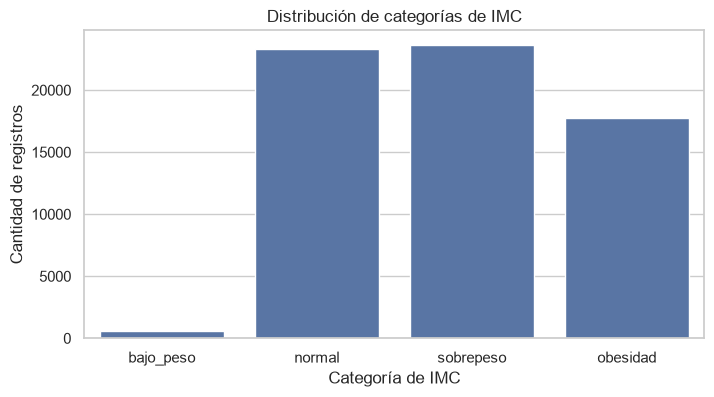

In [112]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="bmi_category",
    order=["bajo_peso", "normal", "sobrepeso", "obesidad"]
)

plt.title("Distribución de categorías de IMC")
plt.xlabel("Categoría de IMC")
plt.ylabel("Cantidad de registros")

plt.show()

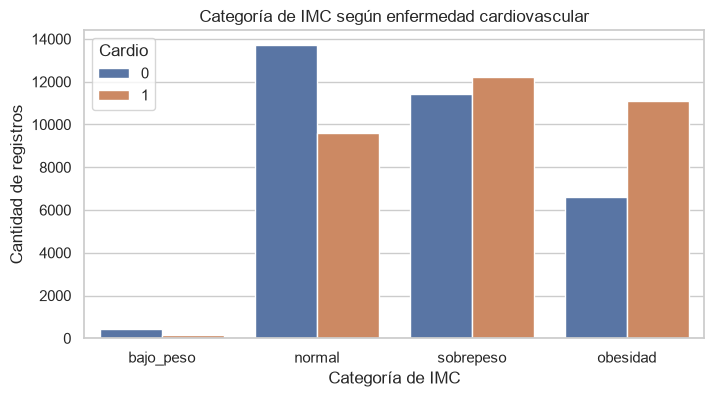

In [113]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="bmi_category",
    hue="cardio",
    order=["bajo_peso", "normal", "sobrepeso", "obesidad"]
)

plt.title("Categoría de IMC según enfermedad cardiovascular")
plt.xlabel("Categoría de IMC")
plt.ylabel("Cantidad de registros")
plt.legend(title="Cardio")

plt.show()

In [114]:
# Calcular porcentaje de pacientes con enfermedad cardiovascular en cada categoría de IMC
bmi_cardio_pct = (
    df.groupby("bmi_category")["cardio"]
    .mean()
    .reset_index()
)

bmi_cardio_pct["Porcentaje_cardio_1"] = bmi_cardio_pct["cardio"] * 100

bmi_cardio_pct = bmi_cardio_pct.set_index("bmi_category").loc[
    ["bajo_peso", "normal", "sobrepeso", "obesidad"]
].reset_index()

bmi_cardio_pct

,bmi_category,cardio,Porcentaje_cardio_1
0,bajo_peso,0.27,27.13
1,normal,0.41,41.19
2,sobrepeso,0.52,51.63
3,obesidad,0.63,62.76


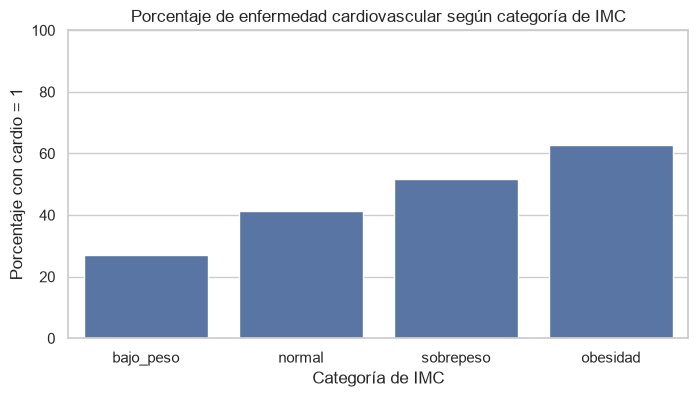

In [115]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=bmi_cardio_pct,
    x="bmi_category",
    y="Porcentaje_cardio_1",
    order=["bajo_peso", "normal", "sobrepeso", "obesidad"]
)

plt.title("Porcentaje de enfermedad cardiovascular según categoría de IMC")
plt.xlabel("Categoría de IMC")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creacion de indicador de obesidad

In [116]:
# Crear variable binaria de obesidad
df["obesity"] = (df["bmi"] >= 30).astype(int)

# Revisar distribución
df["obesity"].value_counts()

obesity
0    47590
1    17717
Name: count, dtype: int64

In [117]:
# Porcentaje de obesidad
df["obesity"].value_counts(normalize=True).sort_index() * 100

obesity
0   72.87
1   27.13
Name: proportion, dtype: float64

In [118]:
# relacion entre obesidad y enfermedad cardiovascular
obesity_cardio_pct = (
    df.groupby("obesity")["cardio"]
    .mean()
    .reset_index()
)

obesity_cardio_pct["Porcentaje_cardio_1"] = obesity_cardio_pct["cardio"] * 100

obesity_cardio_pct

,obesity,cardio,Porcentaje_cardio_1
0,0,0.46,46.19
1,1,0.63,62.76


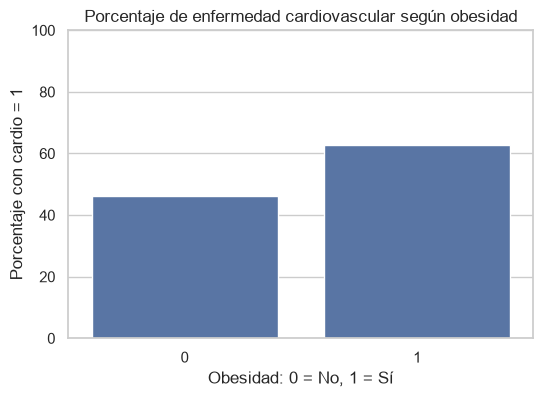

In [119]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=obesity_cardio_pct,
    x="obesity",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según obesidad")
plt.xlabel("Obesidad: 0 = No, 1 = Sí")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creacion de categorias de presion arterial

In [120]:
# Crear categorías de presión arterial
def clasificar_presion(row):
    ap_hi = row["ap_hi"]
    ap_lo = row["ap_lo"]
    
    if ap_hi < 120 and ap_lo < 80:
        return "normal"
    elif 120 <= ap_hi < 130 and ap_lo < 80:
        return "elevada"
    elif (130 <= ap_hi < 140) or (80 <= ap_lo < 90):
        return "hipertension_etapa_1"
    else:
        return "hipertension_etapa_2"

df["bp_category"] = df.apply(clasificar_presion, axis=1)

# Revisar distribución
df["bp_category"].value_counts()

bp_category
hipertension_etapa_1    36827
hipertension_etapa_2    16079
normal                   9337
elevada                  3064
Name: count, dtype: int64

In [121]:
bp_order = [
    "normal",
    "elevada",
    "hipertension_etapa_1",
    "hipertension_etapa_2"
]

df["bp_category"].value_counts().reindex(bp_order)

bp_category
normal                   9337
elevada                  3064
hipertension_etapa_1    36827
hipertension_etapa_2    16079
Name: count, dtype: int64

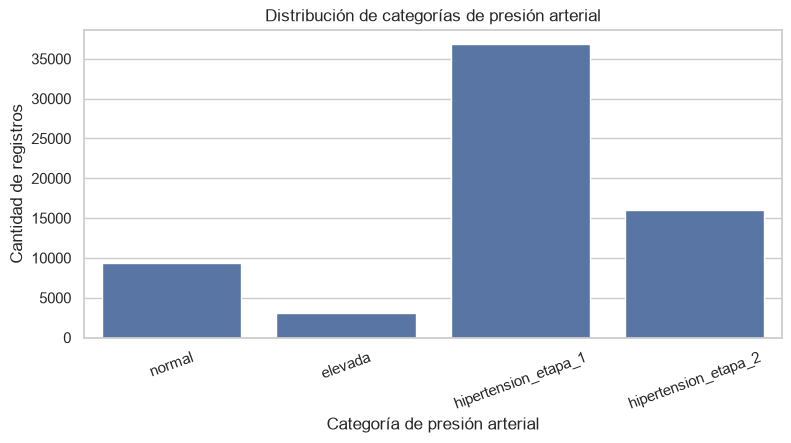

In [122]:
plt.figure(figsize=(9, 4))

sns.countplot(
    data=df,
    x="bp_category",
    order=bp_order
)

plt.title("Distribución de categorías de presión arterial")
plt.xlabel("Categoría de presión arterial")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=20)

plt.show()

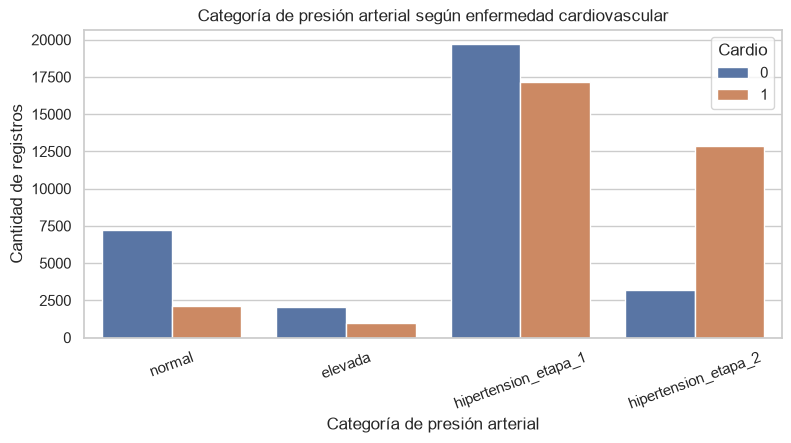

In [123]:
# relación entre presión arterial y enfermedad cardiovascular
plt.figure(figsize=(9, 4))

sns.countplot(
    data=df,
    x="bp_category",
    hue="cardio",
    order=bp_order
)

plt.title("Categoría de presión arterial según enfermedad cardiovascular")
plt.xlabel("Categoría de presión arterial")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=20)
plt.legend(title="Cardio")

plt.show()

In [124]:
bp_cardio_pct = (
    df.groupby("bp_category")["cardio"]
    .mean()
    .reset_index()
)

bp_cardio_pct["Porcentaje_cardio_1"] = bp_cardio_pct["cardio"] * 100

bp_cardio_pct = bp_cardio_pct.set_index("bp_category").reindex(bp_order).reset_index()

bp_cardio_pct

,bp_category,cardio,Porcentaje_cardio_1
0,normal,0.23,22.53
1,elevada,0.33,32.51
2,hipertension_etapa_1,0.47,46.52
3,hipertension_etapa_2,0.80,80.04


In [125]:
bp_cardio_pct = (
    df.groupby("bp_category")["cardio"]
    .mean()
    .reset_index()
)

bp_cardio_pct["Porcentaje_cardio_1"] = bp_cardio_pct["cardio"] * 100

bp_cardio_pct = bp_cardio_pct.set_index("bp_category").reindex(bp_order).reset_index()

bp_cardio_pct

,bp_category,cardio,Porcentaje_cardio_1
0,normal,0.23,22.53
1,elevada,0.33,32.51
2,hipertension_etapa_1,0.47,46.52
3,hipertension_etapa_2,0.80,80.04


## Creacion de indicador de hipertensión

In [126]:
# Crear variable binaria de hipertensión
df["hypertension"] = df["bp_category"].isin(
    ["hipertension_etapa_1", "hipertension_etapa_2"]
).astype(int)

# Revisar distribución
df["hypertension"].value_counts().sort_index()

hypertension
0    12401
1    52906
Name: count, dtype: int64

In [127]:
# Distribución porcentual
df["hypertension"].value_counts(normalize=True).sort_index() * 100

hypertension
0   18.99
1   81.01
Name: proportion, dtype: float64

In [128]:
# relación entre presión arterial y enfermedad cardiovascular

hypertension_cardio_pct = (
    df.groupby("hypertension")["cardio"]
    .mean()
    .reset_index()
)

hypertension_cardio_pct["Porcentaje_cardio_1"] = hypertension_cardio_pct["cardio"] * 100

hypertension_cardio_pct

,hypertension,cardio,Porcentaje_cardio_1
0,0,0.25,25.00
1,1,0.57,56.71


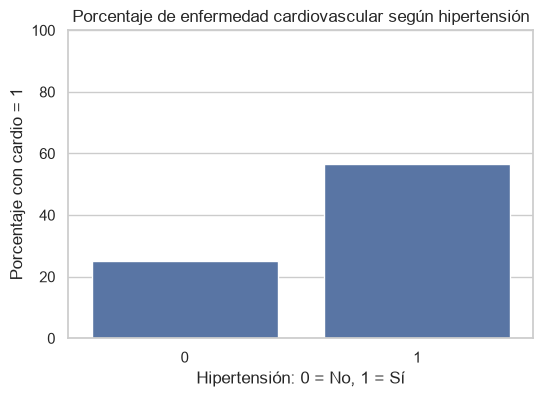

In [129]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=hypertension_cardio_pct,
    x="hypertension",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según hipertensión")
plt.xlabel("Hipertensión: 0 = No, 1 = Sí")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creación del riesgo metabólico

In [130]:
# Crear indicador de riesgo metabólico
df["metabolic_risk"] = (
    (df["cholesterol"] > 1) |
    (df["gluc"] > 1) |
    (df["obesity"] == 1)
).astype(int)

# Revisar distribución
df["metabolic_risk"].value_counts().sort_index()

metabolic_risk
0    34594
1    30713
Name: count, dtype: int64

In [131]:
# Distribución porcentual
df["metabolic_risk"].value_counts(normalize=True).sort_index() * 100

metabolic_risk
0   52.97
1   47.03
Name: proportion, dtype: float64

In [132]:
metabolic_cardio_pct = (
    df.groupby("metabolic_risk")["cardio"]
    .mean()
    .reset_index()
)

metabolic_cardio_pct["Porcentaje_cardio_1"] = metabolic_cardio_pct["cardio"] * 100

metabolic_cardio_pct

,metabolic_risk,cardio,Porcentaje_cardio_1
0,0,0.41,41.00
1,1,0.62,61.60


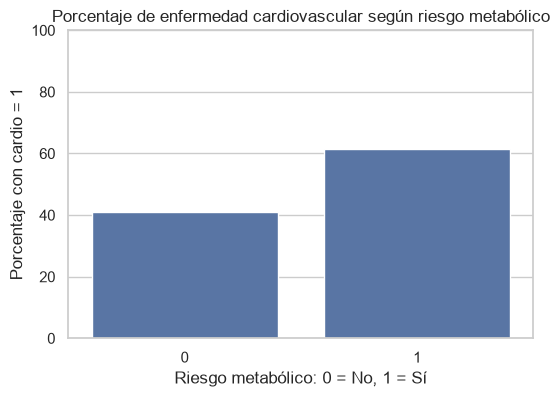

In [133]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=metabolic_cardio_pct,
    x="metabolic_risk",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según riesgo metabólico")
plt.xlabel("Riesgo metabólico: 0 = No, 1 = Sí")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creacion de indicador de riesgo por estilo de vida

In [134]:
# Crear indicador de riesgo por estilo de vida
df["lifestyle_risk"] = (
    (df["smoke"] == 1) |
    (df["alco"] == 1) |
    (df["active"] == 0)
).astype(int)

# Revisar distribución
df["lifestyle_risk"].value_counts().sort_index()

lifestyle_risk
0    45543
1    19764
Name: count, dtype: int64

In [135]:
# Distribución porcentual
df["lifestyle_risk"].value_counts(normalize=True).sort_index() * 100

lifestyle_risk
0   69.74
1   30.26
Name: proportion, dtype: float64

In [136]:
lifestyle_cardio_pct = (
    df.groupby("lifestyle_risk")["cardio"]
    .mean()
    .reset_index()
)

lifestyle_cardio_pct["Porcentaje_cardio_1"] = lifestyle_cardio_pct["cardio"] * 100

lifestyle_cardio_pct

,lifestyle_risk,cardio,Porcentaje_cardio_1
0,0,0.50,50.40
1,1,0.51,51.36


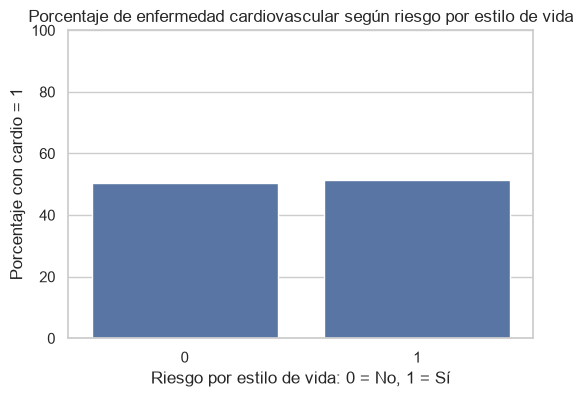

In [137]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=lifestyle_cardio_pct,
    x="lifestyle_risk",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según riesgo por estilo de vida")
plt.xlabel("Riesgo por estilo de vida: 0 = No, 1 = Sí")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

## Creación de indicador de riesgo cardio vascular

In [138]:
# Crear puntaje general de riesgo cardiovascular
df["risk_score"] = (
    df["hypertension"] +
    df["obesity"] +
    (df["cholesterol"] > 1).astype(int) +
    (df["gluc"] > 1).astype(int) +
    (df["smoke"] == 1).astype(int) +
    (df["active"] == 0).astype(int)
)

# Revisar distribución del puntaje
df["risk_score"].value_counts().sort_index()

risk_score
0     6100
1    22851
2    20644
3    10711
4     4225
5      725
6       51
Name: count, dtype: int64

In [139]:
# Porcentaje de enfermedad cardiovascular según puntaje de riesgo
risk_score_cardio_pct = (
    df.groupby("risk_score")["cardio"]
    .mean()
    .reset_index()
)

risk_score_cardio_pct["Porcentaje_cardio_1"] = risk_score_cardio_pct["cardio"] * 100

risk_score_cardio_pct

,risk_score,cardio,Porcentaje_cardio_1
0,0,0.21,20.54
1,1,0.43,43.39
2,2,0.55,54.60
3,3,0.66,66.11
4,4,0.71,70.84
5,5,0.76,76.00
6,6,0.75,74.51


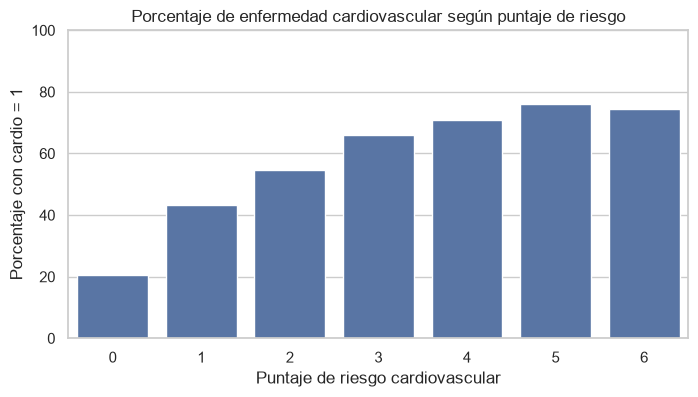

In [140]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=risk_score_cardio_pct,
    x="risk_score",
    y="Porcentaje_cardio_1"
)

plt.title("Porcentaje de enfermedad cardiovascular según puntaje de riesgo")
plt.xlabel("Puntaje de riesgo cardiovascular")
plt.ylabel("Porcentaje con cardio = 1")
plt.ylim(0, 100)

plt.show()

In [141]:
# Crear nuevas variables de presión arterial

# 1. Presión de pulso: diferencia entre presión sistólica y diastólica
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

# 2. Presión arterial media
# Fórmula correcta: (2 * presión diastólica + presión sistólica) / 3
df["mean_arterial_pressure"] = (2 * df["ap_lo"] + df["ap_hi"]) / 3

# 3. Interacción entre edad y presión sistólica
df["age_pressure"] = df["age_years"] * df["ap_hi"]

# Revisar las nuevas variables
df[["ap_hi", "ap_lo", "age_years", 
    "pulse_pressure", 
    "mean_arterial_pressure", 
    "age_pressure"]].head()

,ap_hi,ap_lo,age_years,pulse_pressure,mean_arterial_pressure,age_pressure
0,110,80,50,30,90.00,5500
1,140,90,55,50,106.67,7700
2,130,70,51,60,90.00,6630
3,150,100,48,50,116.67,7200
4,100,60,47,40,73.33,4700


In [142]:
# Variables nuevas a analizar
nuevas_vars = [
    "pulse_pressure",
    "mean_arterial_pressure",
    "age_pressure"
]

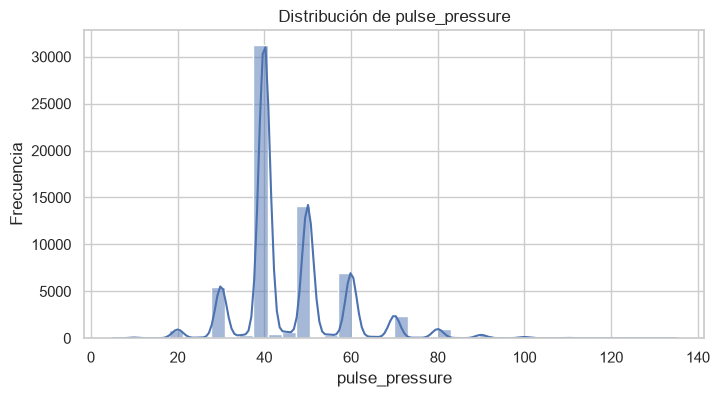

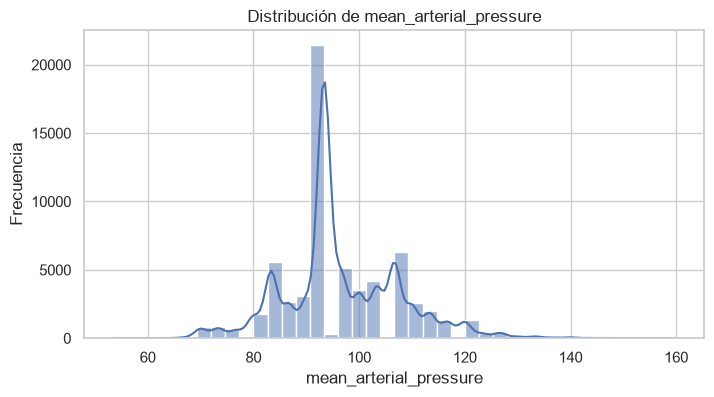

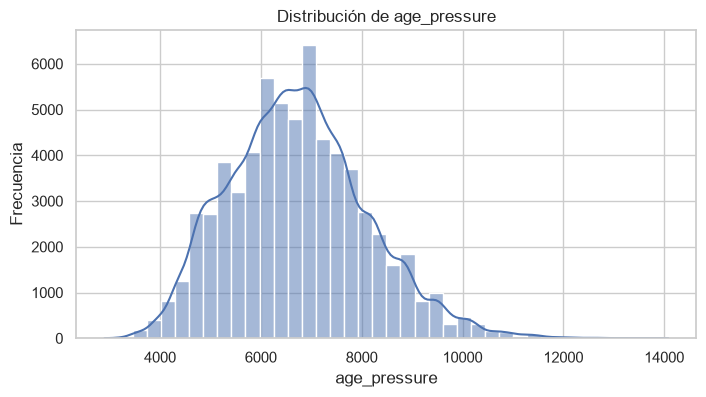

In [143]:
for var in nuevas_vars:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(
        data=df,
        x=var,
        bins=40,
        kde=True
    )
    
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.show()

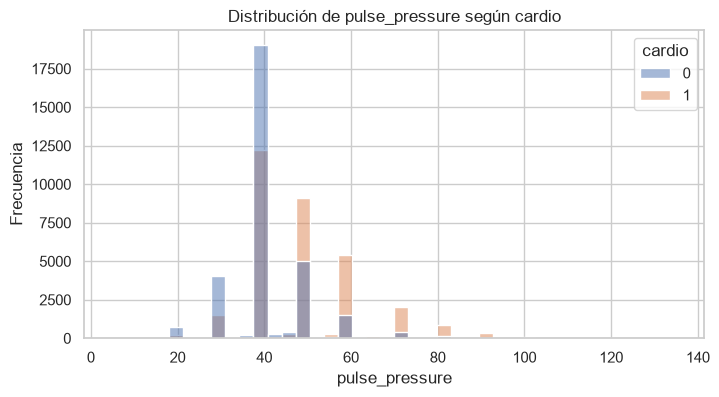

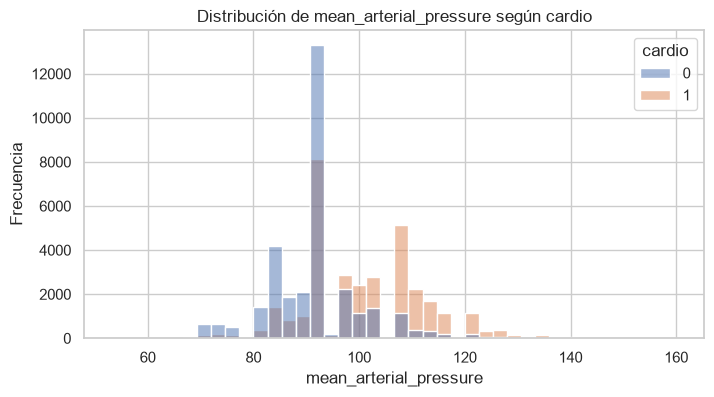

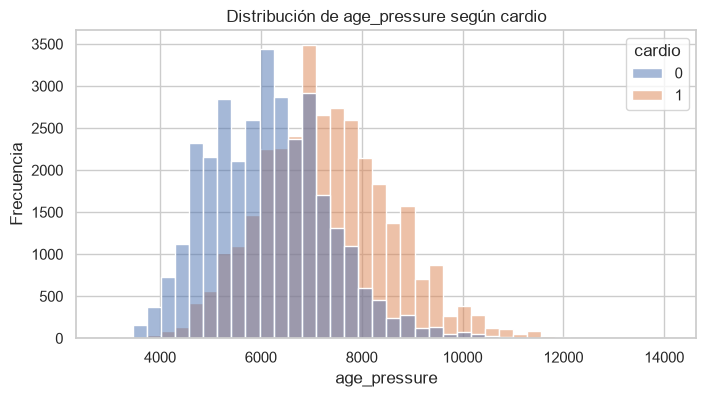

In [144]:
for var in nuevas_vars:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(
        data=df,
        x=var,
        hue="cardio",
        bins=40,
        multiple="layer",
        alpha=0.5
    )
    
    plt.title(f"Distribución de {var} según cardio")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.show()

## Revision final

In [145]:
# Variables creadas durante Feature Engineering
variables_creadas = [
    "bmi",
    "bmi_category",
    "obesity",
    "bp_category",
    "hypertension",
    "metabolic_risk",
    "lifestyle_risk",
    "risk_score",
    "pulse_pressure",
    "mean_arterial_pressure",
    "age_pressure"
]

# Visualizar primeras filas de las variables creadas
df[variables_creadas].head()

,bmi,bmi_category,obesity,bp_category,hypertension,metabolic_risk,lifestyle_risk,risk_score,pulse_pressure,mean_arterial_pressure,age_pressure
0,21.97,normal,0,hipertension_etapa_1,1,0,0,1,30,90.00,5500
1,34.93,obesidad,1,hipertension_etapa_2,1,1,0,3,50,106.67,7700
2,23.51,normal,0,hipertension_etapa_1,1,1,1,3,60,90.00,6630
3,28.71,sobrepeso,0,hipertension_etapa_2,1,0,0,1,50,116.67,7200
4,23.01,normal,0,normal,0,0,1,1,40,73.33,4700


In [146]:
# Revisar columnas finales del dataset
df.columns.tolist()

['age_years',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio',
 'bmi',
 'bmi_category',
 'obesity',
 'bp_category',
 'hypertension',
 'metabolic_risk',
 'lifestyle_risk',
 'risk_score',
 'pulse_pressure',
 'mean_arterial_pressure',
 'age_pressure']

## Creación de variables de presion arterial

In [147]:
# Seleccionar variables numéricas para correlación
numeric_cols_fe = df.select_dtypes(include=["int64", "float64"]).columns

numeric_cols_fe

Index(['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi',
       'obesity', 'hypertension', 'metabolic_risk', 'lifestyle_risk',
       'risk_score', 'pulse_pressure', 'mean_arterial_pressure',
       'age_pressure'],
      dtype='str')

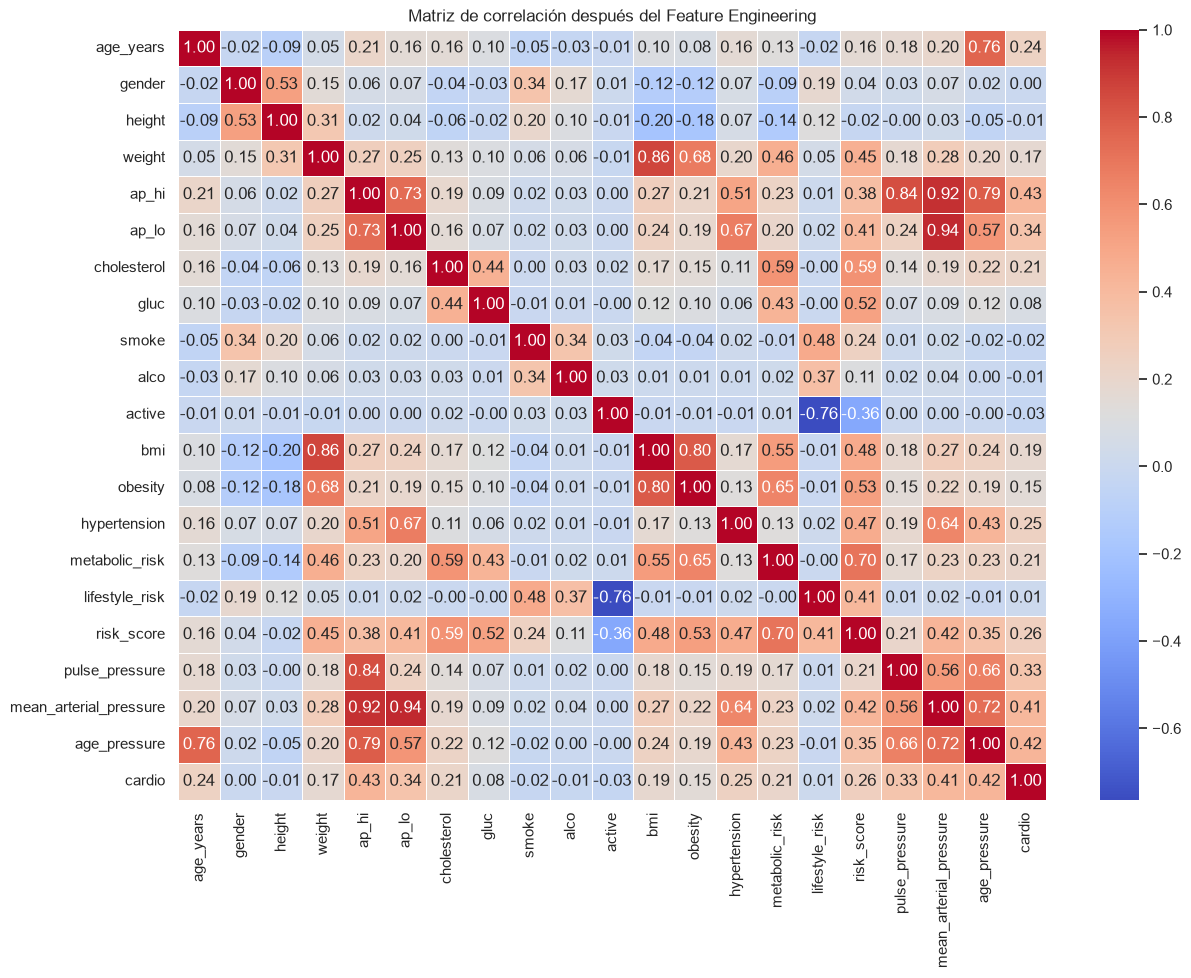

In [148]:
numeric_cols_fe = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_cols_fe = [col for col in numeric_cols_fe if col != "cardio"] + ["cardio"]

correlation_matrix_fe = df[numeric_cols_fe].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix_fe,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación después del Feature Engineering")
plt.show()

ap_hi
ap_lo
wheigth
obesity
active

In [149]:
# Correlación de variables numéricas con cardio
correlation_with_cardio_fe = (
    correlation_matrix_fe["cardio"]
    .drop("cardio")
    .sort_values(ascending=False)
)

correlation_with_cardio_fe

ap_hi                     0.43
age_pressure              0.42
mean_arterial_pressure    0.41
ap_lo                     0.34
pulse_pressure            0.33
risk_score                0.26
hypertension              0.25
age_years                 0.24
cholesterol               0.21
metabolic_risk            0.21
bmi                       0.19
weight                    0.17
obesity                   0.15
gluc                      0.08
lifestyle_risk            0.01
gender                    0.00
height                   -0.01
alco                     -0.01
smoke                    -0.02
active                   -0.03
Name: cardio, dtype: float64

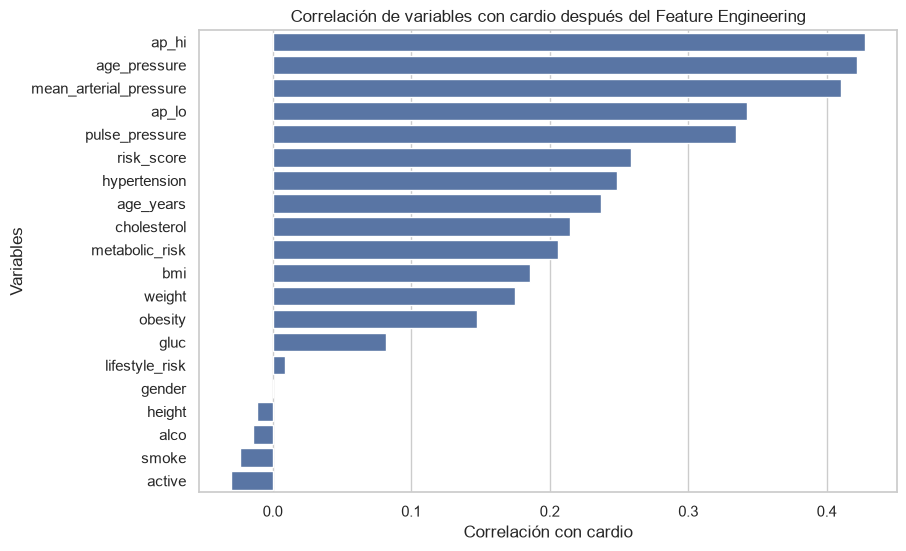

In [150]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=correlation_with_cardio_fe.values,
    y=correlation_with_cardio_fe.index
)

plt.title("Correlación de variables con cardio después del Feature Engineering")
plt.xlabel("Correlación con cardio")
plt.ylabel("Variables")

plt.show()

## Prueba chi-cuadrado para variables categoricas

In [151]:

# H0: No hay asociación entre la categoría de presión arterial y la presencia de enfermedad cardiovascular (cardio).
# H1: Existe una asociación entre la categoría de presión arterial y la presencia de enfermedad cardiovascular (cardio).
from scipy.stats import chi2_contingency

# Tabla de contingencia entre categoría de presión arterial y cardio
tabla_bp_cardio = pd.crosstab(df["bp_category"], df["cardio"])

tabla_bp_cardio

cardio,0,1
bp_category,,
elevada,2068,996
hipertension_etapa_1,19694,17133
hipertension_etapa_2,3210,12869
normal,7233,2104


In [152]:
# Prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(tabla_bp_cardio)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Grados de libertad: {dof}")

Chi-cuadrado: 9162.3938
p-value: 0.000000
Grados de libertad: 3


Existe correlacion entre las variables

In [153]:


# H0: No hay asociación entre la categoría de IMC y la presencia de enfermedad cardiovascular.
# H1: Existe asociación entre la categoría de IMC y la presencia de enfermedad cardiovascular.

tabla_bmi_category = pd.crosstab(df["bmi_category"], df["cardio"])

print("Tabla de contingencia: bmi_category vs cardio")
display(tabla_bmi_category)

chi2, p_value, dof, expected = chi2_contingency(tabla_bmi_category)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Grados de libertad: {dof}")

if p_value < 0.05:
    print("Conclusión: Se rechaza H0. Existe asociación estadísticamente significativa entre bmi_category y cardio.")
else:
    print("Conclusión: No se rechaza H0. No hay evidencia suficiente de asociación entre bmi_category y cardio.")

Tabla de contingencia: bmi_category vs cardio


cardio,0,1
bmi_category,,
bajo_peso,454,169
normal,13721,9609
obesidad,6597,11120
sobrepeso,11433,12204


Chi-cuadrado: 2023.0262
p-value: 0.000000
Grados de libertad: 3
Conclusión: Se rechaza H0. Existe asociación estadísticamente significativa entre bmi_category y cardio.


## Guardar datasets

In [154]:
# Guardar dataset completo con todas las variables originales limpias y derivadas
df.to_csv("cardio_features_full.csv", index=False)

print("Dataset completo guardado como cardio_features_full.csv")
print("Dimensiones:", df.shape)

Dataset completo guardado como cardio_features_full.csv
Dimensiones: (65307, 23)


# Resumen de variables creadas en Feature Engineering

| Variable creada  | ¿Qué indica?                                         | Variables utilizadas                                                | Criterio / fórmula utilizada                                                                                                                                                                            | Tipo de variable            | ¿Qué indica cada valor?                                                                                                                         |
| ---------------- | ---------------------------------------------------- | ------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| `bmi`            | Índice de Masa Corporal de la persona                | `weight`, `height`                                                  | `bmi = weight / (height / 100)^2`                                                                                                                                                                       | Numérica continua           | Valor numérico del IMC. A mayor valor, mayor relación peso-altura.                                                                              |
| `bmi_category`   | Clasificación del IMC en categorías                  | `bmi`                                                               | Bajo peso: `< 18.5`; Normal: `18.5 - 24.9`; Sobrepeso: `25 - 29.9`; Obesidad: `>= 30`                                                                                                                   | Categórica ordinal          | `bajo_peso`: IMC bajo; `normal`: IMC saludable; `sobrepeso`: IMC elevado; `obesidad`: IMC igual o mayor a 30.                                   |
| `obesity`        | Indica si la persona presenta obesidad               | `bmi`                                                               | `obesity = 1` si `bmi >= 30`, caso contrario `0`                                                                                                                                                        | Binaria                     | `0`: no presenta obesidad; `1`: presenta obesidad.                                                                                              |
| `bp_category`    | Clasificación de la presión arterial                 | `ap_hi`, `ap_lo`                                                    | Normal: `ap_hi < 120` y `ap_lo < 80`; Elevada: `120 <= ap_hi < 130` y `ap_lo < 80`; Hipertensión etapa 1: `130 <= ap_hi < 140` o `80 <= ap_lo < 90`; Hipertensión etapa 2: valores superiores a etapa 1 | Categórica ordinal          | `normal`: presión normal; `elevada`: presión elevada; `hipertension_etapa_1`: hipertensión moderada; `hipertension_etapa_2`: hipertensión alta. |
| `hypertension`   | Indica si la persona presenta hipertensión           | `bp_category`                                                       | `hypertension = 1` si `bp_category` es `hipertension_etapa_1` o `hipertension_etapa_2`                                                                                                                  | Binaria                     | `0`: no presenta hipertensión; `1`: presenta hipertensión.                                                                                      |
| `metabolic_risk` | Indica presencia de riesgo metabólico                | `cholesterol`, `gluc`, `obesity`                                    | `metabolic_risk = 1` si `cholesterol > 1` o `gluc > 1` o `obesity = 1`                                                                                                                                  | Binaria                     | `0`: no presenta riesgo metabólico según las variables usadas; `1`: presenta al menos un factor metabólico de riesgo.                           |
| `lifestyle_risk` | Indica presencia de riesgo por hábitos de vida       | `smoke`, `alco`, `active`                                           | `lifestyle_risk = 1` si `smoke = 1` o `alco = 1` o `active = 0`                                                                                                                                         | Binaria                     | `0`: no fuma, no consume alcohol y realiza actividad física; `1`: presenta al menos un hábito de riesgo.                                        |
| `risk_score`     | Puntaje general de acumulación de factores de riesgo | `hypertension`, `obesity`, `cholesterol`, `gluc`, `smoke`, `active` | Suma de factores: hipertensión + obesidad + colesterol elevado + glucosa elevada + tabaquismo + falta de actividad física                                                                               | Numérica discreta / ordinal | Valor de `0` a `6`. Mientras mayor sea el puntaje, mayor cantidad de factores de riesgo acumula la persona.                                     |
| `pulse_pressure` | Diferencia entre la presión sistólica y diastólica | `ap_hi`, `ap_lo` | `pulse_pressure = ap_hi - ap_lo` | Numérica continua | Valor numérico de la diferencia entre presión alta y baja. A mayor valor, mayor separación entre presión sistólica y diastólica. |
| `mean_arterial_pressure` | Estimación de la presión arterial media | `ap_hi`, `ap_lo` | `mean_arterial_pressure = (2 * ap_lo + ap_hi) / 3` | Numérica continua | Valor promedio estimado de presión arterial. A mayor valor, mayor presión arterial media. |
| `age_pressure` | Interacción entre edad y presión sistólica | `age_years`, `ap_hi` | `age_pressure = age_years * ap_hi` | Numérica continua | Valor numérico que combina edad y presión sistólica. A mayor valor, mayor carga conjunta entre edad y presión alta. |


## Eliminar variables con redundancia

In [155]:
# Variables a eliminar por redundancia o baja utilidad
vars_eliminar = [
    "ap_hi",
    "ap_lo",
    "weight",
    "obesity",
    "active"
]

# Eliminar solo si existen en el dataframe
df = df.drop(columns=[col for col in vars_eliminar if col in df.columns])

# Verificar columnas restantes
df.columns

Index(['age_years', 'gender', 'height', 'cholesterol', 'gluc', 'smoke', 'alco',
       'cardio', 'bmi', 'bmi_category', 'bp_category', 'hypertension',
       'metabolic_risk', 'lifestyle_risk', 'risk_score', 'pulse_pressure',
       'mean_arterial_pressure', 'age_pressure'],
      dtype='str')

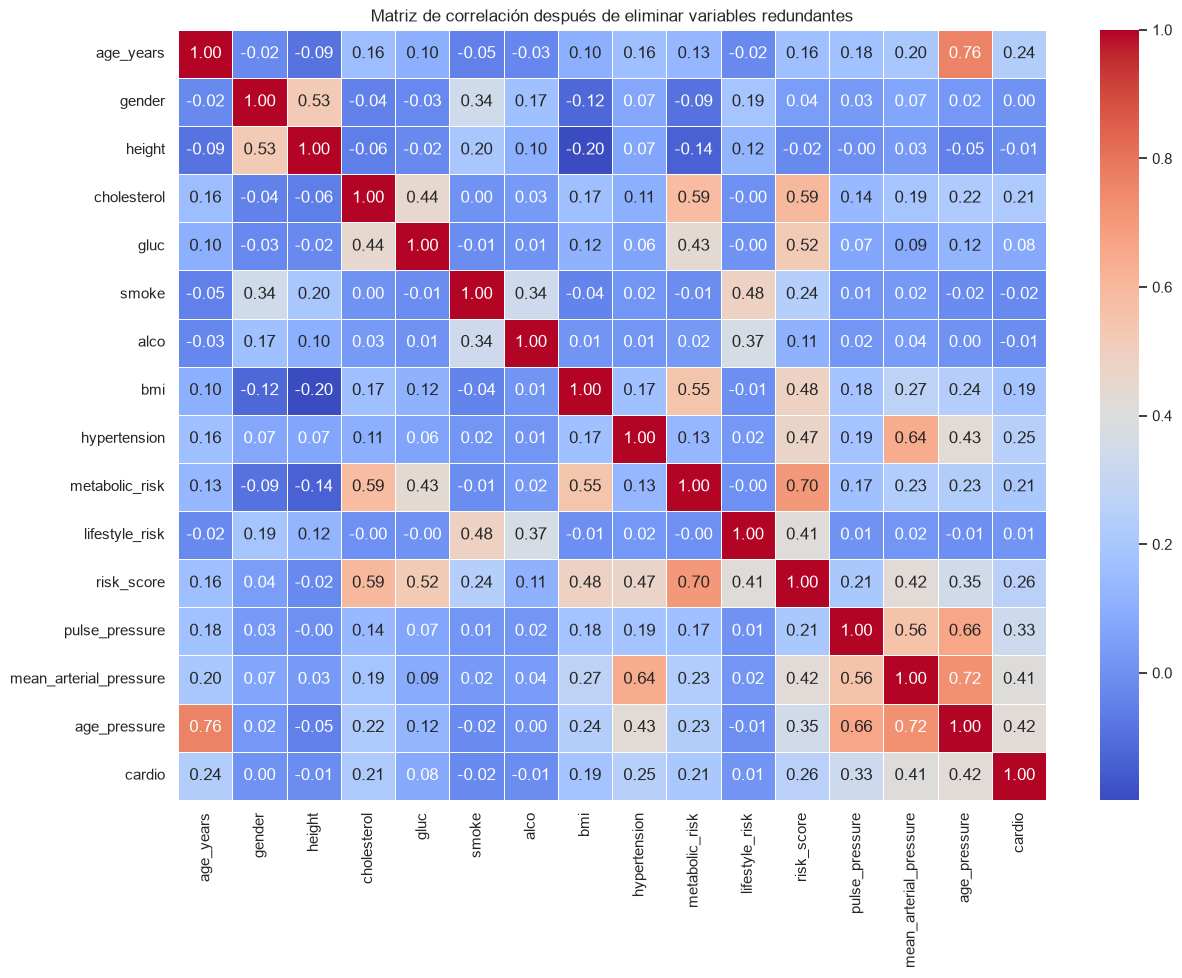

In [156]:
# Asegurar que cardio esté al final
df["cardio"] = df["cardio"].astype(int)

numeric_cols_fe = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_cols_fe = [col for col in numeric_cols_fe if col != "cardio"] + ["cardio"]

correlation_matrix_fe = df[numeric_cols_fe].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix_fe,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación después de eliminar variables redundantes")
plt.show()

In [157]:
# guardar version reducida 1
df.to_csv("cardio_features_reduced1.csv", index=False)


gender 
height
smoke
alco


In [158]:
df_reduced_v2 = df.drop(columns=[
    "gender",
    "height",
    "smoke",
    "alco"
])

In [159]:
# Crear una versión más reducida del dataset
vars_eliminar_v2 = [
    "gender",
    "height",
    "smoke",
    "alco"
]

df_reduced_v2 = df.drop(columns=[col for col in vars_eliminar_v2 if col in df.columns])

# Verificar columnas restantes
df_reduced_v2.columns

Index(['age_years', 'cholesterol', 'gluc', 'cardio', 'bmi', 'bmi_category',
       'bp_category', 'hypertension', 'metabolic_risk', 'lifestyle_risk',
       'risk_score', 'pulse_pressure', 'mean_arterial_pressure',
       'age_pressure'],
      dtype='str')

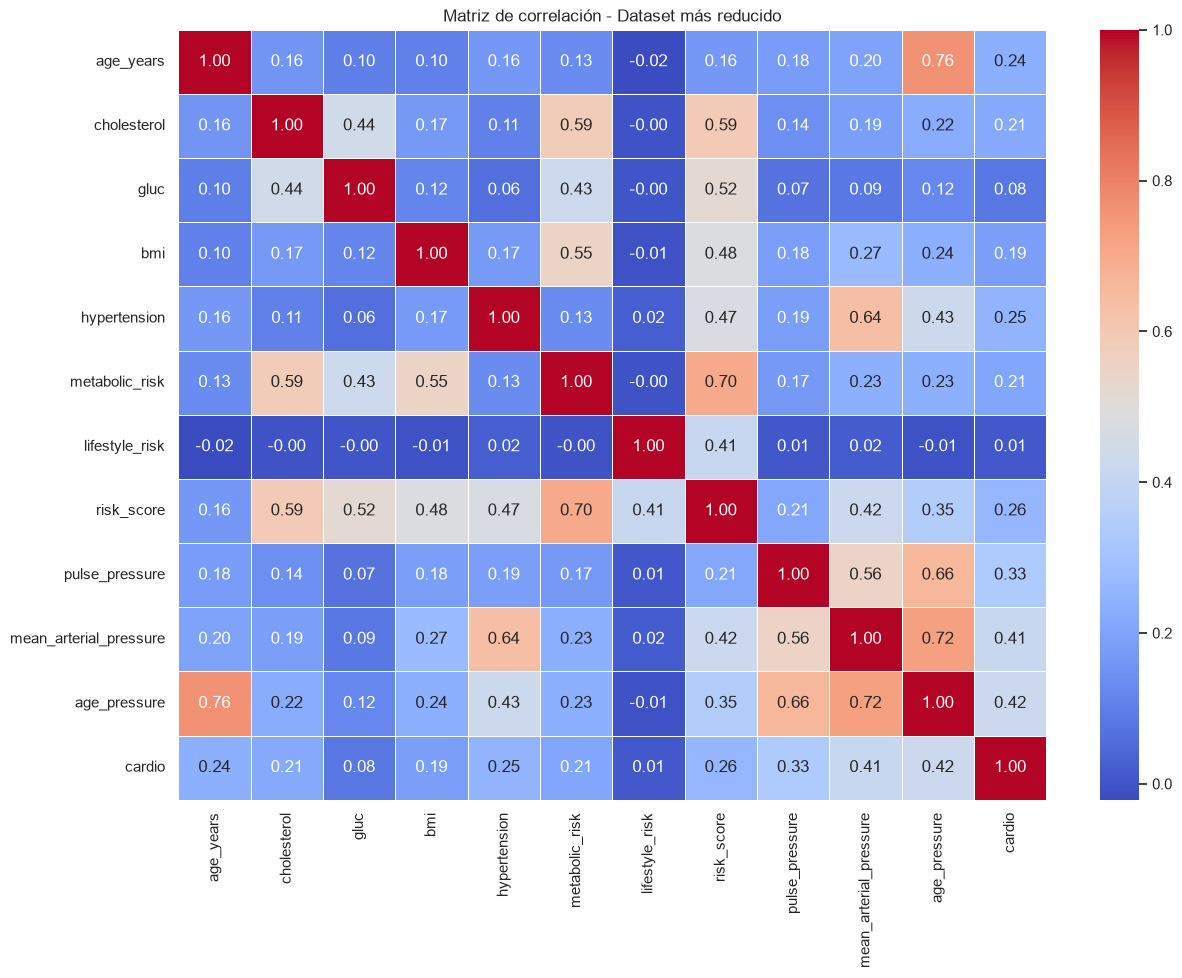

In [160]:
# Asegurar que cardio quede al final
df_reduced_v2["cardio"] = df_reduced_v2["cardio"].astype(int)

numeric_cols_v2 = df_reduced_v2.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols_v2 = [col for col in numeric_cols_v2 if col != "cardio"] + ["cardio"]

correlation_matrix_v2 = df_reduced_v2[numeric_cols_v2].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix_v2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación - Dataset más reducido")
plt.show()

In [161]:
# Guardar dataset reducido versión 2
df_reduced_v2.to_csv("cardio_features_reduced2.csv", index=False)

## Otras versiones 

In [162]:
df_full = pd.read_csv("cardio_features_full.csv")

In [163]:
# Dataset V3: presión original sin derivadas de presión
df_reduced_v3 = df_full.copy()

vars_eliminar_v3 = [
    "pulse_pressure",
    "mean_arterial_pressure",
    "age_pressure",
    "weight",
    "obesity",
    "active"
]

df_reduced_v3 = df_reduced_v3.drop(
    columns=[col for col in vars_eliminar_v3 if col in df_reduced_v3.columns]
)

df_reduced_v3.columns

Index(['age_years', 'gender', 'height', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'cardio', 'bmi', 'bmi_category', 'bp_category',
       'hypertension', 'metabolic_risk', 'lifestyle_risk', 'risk_score'],
      dtype='str')

In [164]:
# Guardar dataset version 4 sin variables de presión
df_reduced_v3.to_csv("cardio_features_reduced3.csv", index=False)

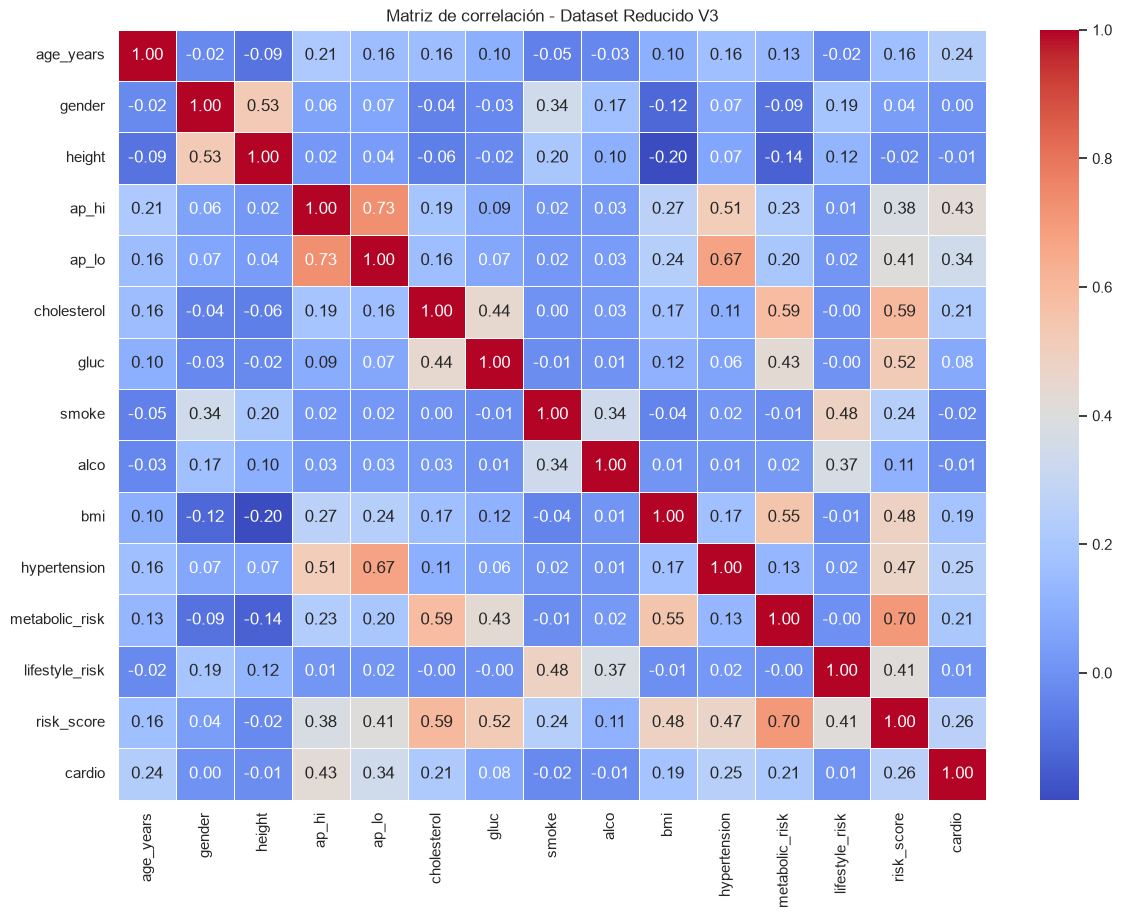

In [165]:
# Asegurar que cardio sea numérica
df_reduced_v3["cardio"] = df_reduced_v3["cardio"].astype(int)

# Seleccionar variables numéricas
numeric_cols_v3 = df_reduced_v3.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Mover cardio al final
numeric_cols_v3 = [col for col in numeric_cols_v3 if col != "cardio"] + ["cardio"]

# Matriz de correlación
correlation_matrix_v3 = df_reduced_v3[numeric_cols_v3].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix_v3,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación - Dataset Reducido V3")
plt.show()